### Imports

In [26]:
import warnings
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import build_database.clean_tables as ct
from build_database import utils
import importlib.resources as pkg_resources
import build_database.databases

# automatically reaload update modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Functions

In [27]:
def alk_gfw_duplicates(df: pd.DataFrame, target_column: str) -> tuple[int, pd.DataFrame]:
    """
    Find duplicate rows in a DataFrame based on the target column.
    """
    if target_column not in df.columns:
        raise ValueError(f"{target_column} not in DataFrame columns")
    dups = df.dropna(subset=[target_column])
    dups = dups[['element', 'species', target_column,'source']].drop_duplicates(subset=['element', 'species', target_column])
    dups = dups[dups.duplicated(subset=['element', 'species'], keep=False)].sort_values(by=['element'])
    dif = dups.groupby(['element', 'species']).nunique()
    unique_count = dif.shape[0]
    return unique_count, dups


def remove_ones_full(equation: pd.Series) -> pd.Series:
    """removes all instances of '1' from a series of equations"""
    ones = re.compile(r'\b1\.0{0,4}\s?')
    return equation.str.replace(ones, '', regex=True)

def equation_duplicates(df: pd.DataFrame, column_of_interest: str) -> tuple[int, pd.DataFrame]:
    """
    Find duplicate rows in a DataFrame based on the equation column.
    """
    if column_of_interest not in df.columns:
        raise ValueError(f"{column_of_interest} not in DataFrame columns")
    # remove all whitespace from the equation column
    dups = pd.DataFrame()
    dups['equation'] = df['equation'].str.replace(' ', '')
    # dups = remove_ones_full(df['equation'])
    dups = df.drop_duplicates(subset=['equation', column_of_interest])
    dups = dups.dropna(subset=[column_of_interest])
    dups = dups[dups.duplicated(subset=['equation'], keep=False)].sort_values(by=['equation'])
    return dups['equation'].nunique(), dups


### Setup

In [28]:
# get databases folder from build_database
database_list = pkg_resources.files('build_database.databases')
database_list = utils.phreeqc_database_list(database_list)

# create Solution Species table
solution_species = ct.compile_solution_species_table(database_list)

# create Solution Master Species table
sms = ct.compile_master_solution_table(database_list, analysis=True)
# drop duplicate rows
before = len(sms)
filter_columns = ['element','species','alk','element_gfw']
sms = sms.drop_duplicates(subset=filter_columns)
after = len(sms)
print(f'Filtered {before - after} duplicate rows from Solution Master Species table')
before = len(solution_species)
filter_columns = solution_species.columns[:-1]
solution_species = solution_species.drop_duplicates(subset=filter_columns)
after = len(solution_species)
print(f'Filtered {before - after} duplicate rows from Solution Species table')

Filtered 253 duplicate rows from Solution Master Species table
Filtered 347 duplicate rows from Solution Species table


Examine DataFrames

In [29]:
solution_species.head()

,equation,log_k,delta_h,gamma,d_w,v_m,millero,activity_water,add_logk,co2_llnl_gamma,erm_ddl,no_check,mole_balance,source
0,HAcetate = HAcetate,0.0,"(0, kJ/mol)",None,None,None,None,None,None,None,None,False,None,llnl.dat
1,Ag+ = Ag+,0.0,"(0, kJ/mol)",None,None,None,None,None,None,None,None,False,None,llnl.dat
2,Al+3 = Al+3,0.0,"(0, kJ/mol)",None,None,None,None,None,None,None,None,False,None,llnl.dat
3,Am+3 = Am+3,0.0,"(0, kJ/mol)",None,None,None,None,None,None,None,None,False,None,llnl.dat
4,Ar = Ar,0.0,"(0, kJ/mol)",None,None,None,None,None,None,None,None,False,None,llnl.dat


In [30]:
sms.head()

,element,species,alk,gfw_formula,element_gfw,source
0,Acetate,HAcetate,0.0,Acetate,59.,#llnl.dat
1,Ag,Ag+,0.0,Ag,107.8682,#llnl.dat
2,Ag(+1),Ag+,0.0,Ag,None,#llnl.dat
3,Ag(+2),Ag+2,0.0,Ag,None,#llnl.dat
4,Al,Al+3,0.0,Al,26.9815,#llnl.dat


## Database Overview 

### How much data does each database have?

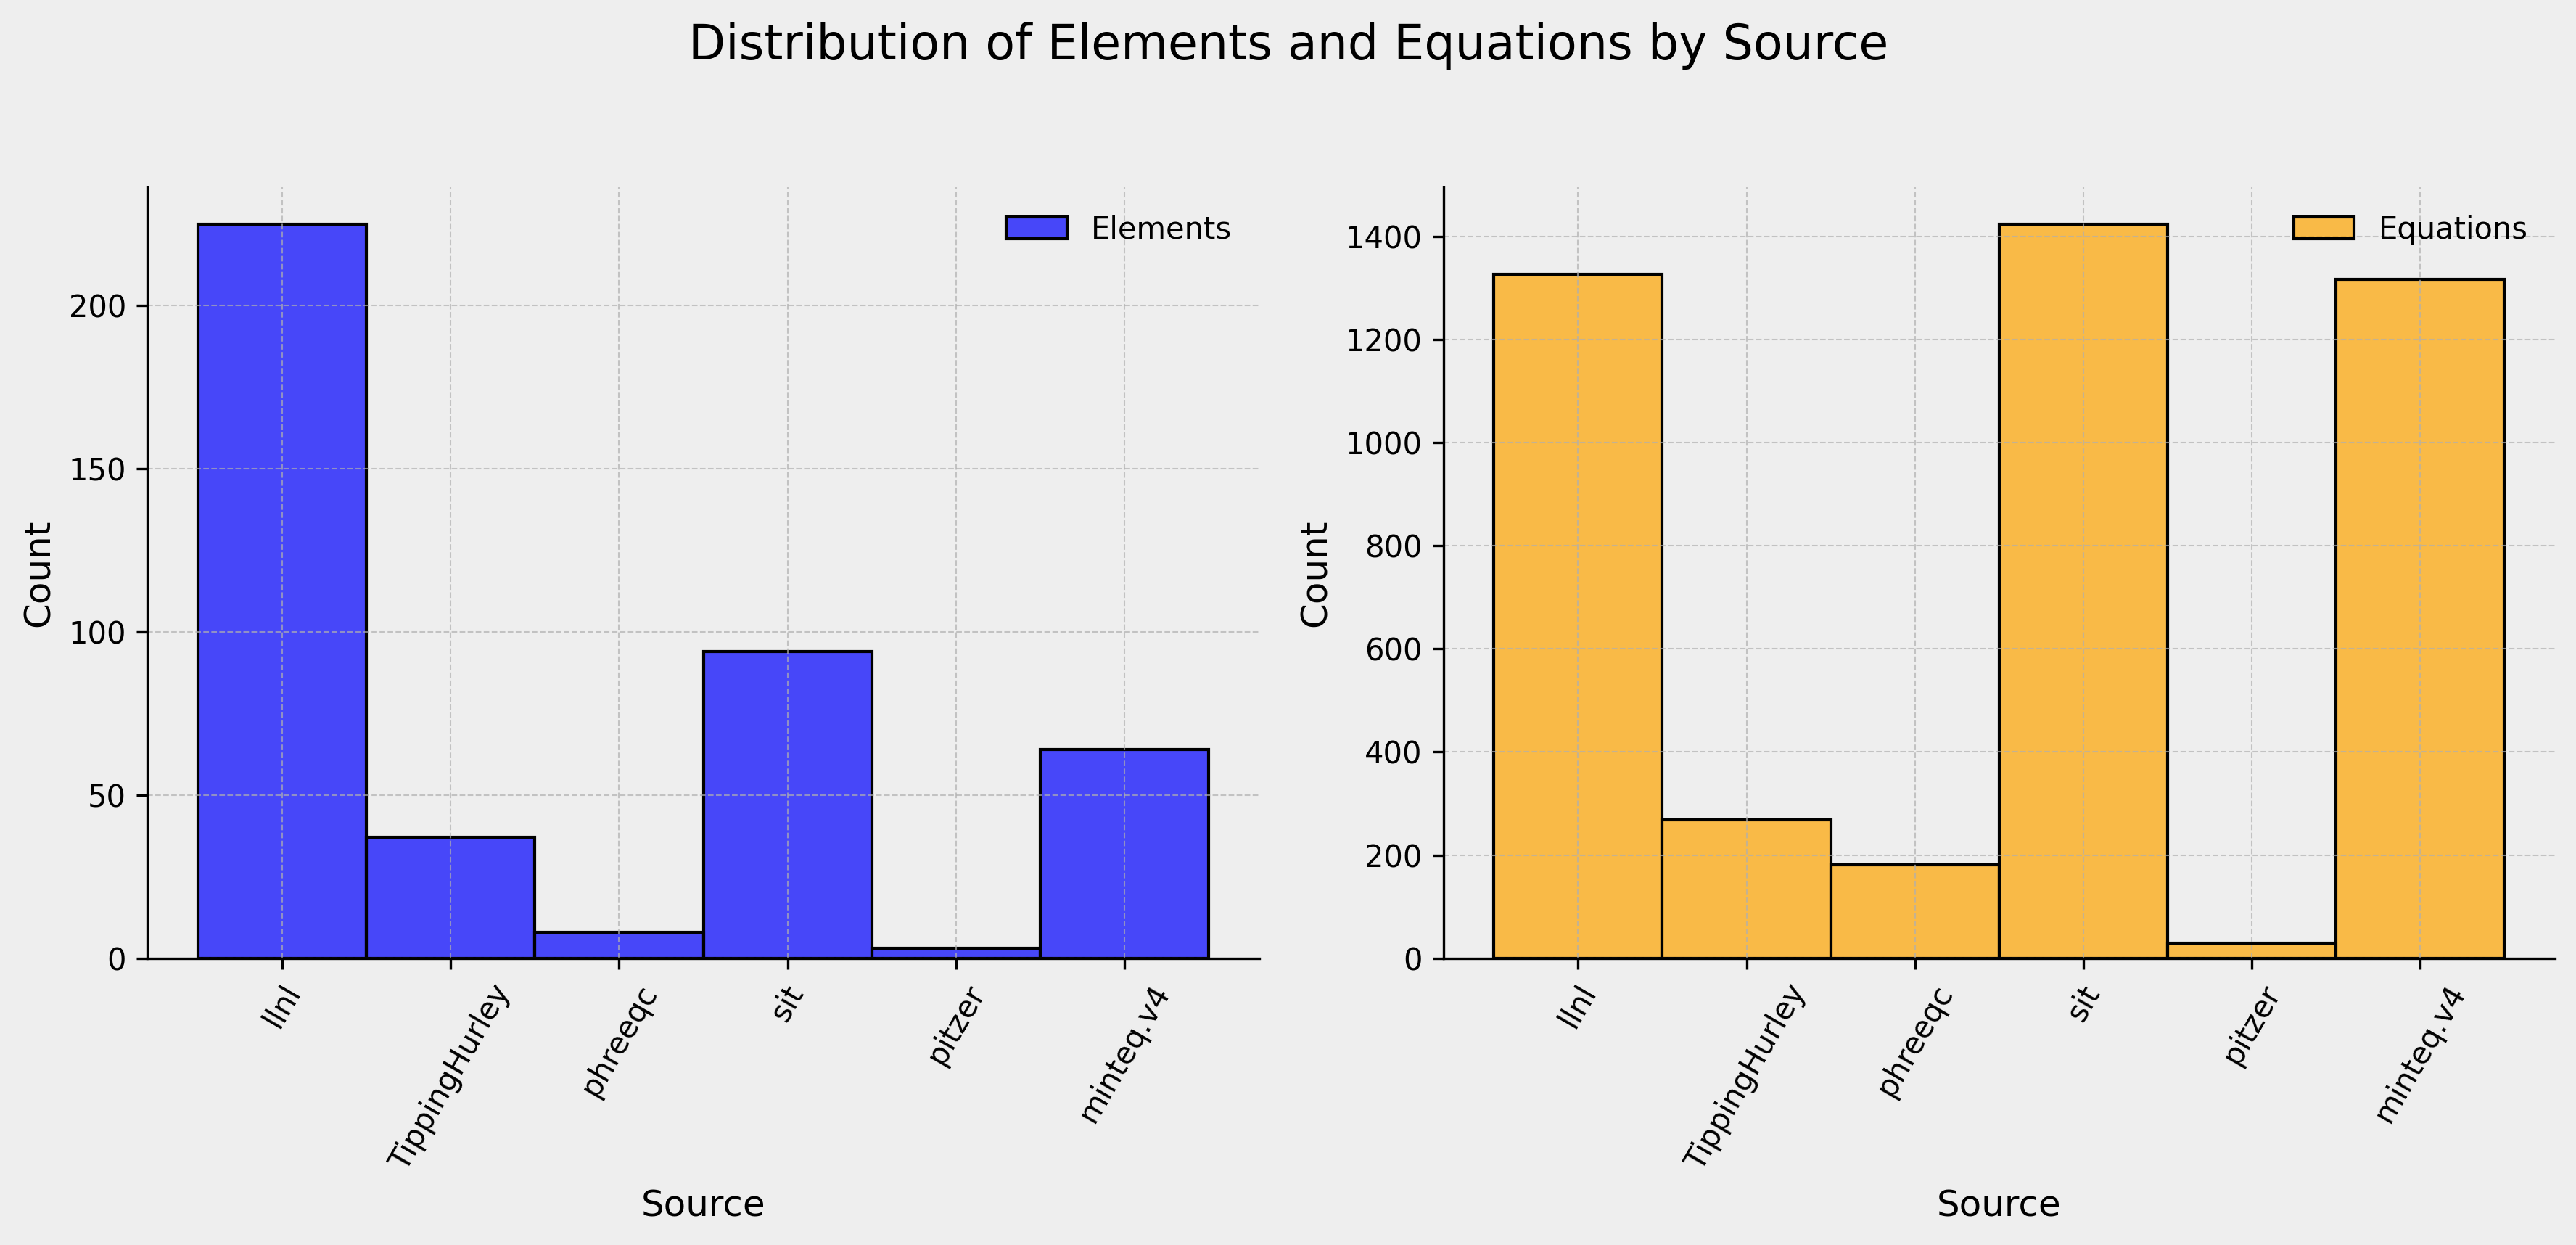

In [31]:
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.facecolor': '#eeeeee',
    'axes.facecolor': '#eeeeee',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300  # High resolution for publication
})

def plot_source_hist(
    df: pd.DataFrame,
    title: str = None,
    rotation: int = 45,
    ax: plt.Axes = None,
    color: str = 'blue',
    label: str = None
) -> None:
    """
    Plot the distribution of conflicting attributes in a DataFrame on the given axes.

    Parameters:
    df (pd.DataFrame): The data frame containing the data to plot.
    title (str): The title of the plot.
    rotation (int): The rotation angle of the x-axis labels.
    ax (plt.Axes): Existing axes to plot on. If None, creates a new figure and axes.
    color (str): Color of the histogram.
    label (str): Label for the histogram (for legend).

    Returns:
    None
    """
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure  # Get the figure from the existing axes

    sns.histplot(data=df, x='source', ax=ax, color=color, label=label, alpha=0.7)
    ax.set_xlabel('Source')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.set_xticks(ax.get_xticks())

    # Adjust xticklabels using re.sub to replace '#', '.dat', and '_'
    substrings_to_replace = ['#', '.dat', '_']
    pattern = "|".join(map(re.escape, substrings_to_replace))

    ax.set_xticklabels(
        [re.sub(pattern, '', label.get_text()) for label in ax.get_xticklabels()],
        rotation=rotation
    )

    if label:
        ax.legend(loc='upper right', frameon=False)

    # Optional: Remove top and right spines for a cleaner look
    sns.despine(ax=ax)

    # Add a grid with reduced opacity for better readability
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)


# Create a figure with 1 row and 2 columns for side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Add a title for the entire figure
fig.suptitle('Distribution of Elements and Equations by Source', fontsize=16)

# Plot the first histogram on the first subplot
plot_source_hist(sms, ax=ax1, rotation=60, color='blue', label='Elements')

# Plot the second histogram on the second subplot
plot_source_hist(solution_species, ax=ax2, rotation=60, color='orange', label='Equations')

# Adjust layout to prevent overlap of subplot titles and labels
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust rect to make room for the suptitle

# Save the figure with both subplots in high resolution
fig.savefig('subplots_combined.png', format='png', bbox_inches='tight', dpi=300)

plt.show()


What is the ratio of elements to sources?

In [32]:
# group by source and count the number of unique elements
source_element_counts = sms.groupby('source')['element'].nunique()
source_element_counts = source_element_counts.reset_index()
source_element_counts = source_element_counts.sort_values(by='element', ascending=False)
source_element_counts = source_element_counts.rename(columns={'element': 'unique_elements'})
source_element_counts['source'] = source_element_counts['source'].str.replace('#', '')

# group by source and count the number of unique equations
source_equation_counts = solution_species.groupby('source')['equation'].nunique()
source_equation_counts = source_equation_counts.reset_index()
source_equation_counts = source_equation_counts.sort_values(by='equation', ascending=False)
source_equation_counts = source_equation_counts.rename(columns={'equation': 'unique_equations'})
source_equation_counts


combined_df = pd.merge(source_element_counts, source_equation_counts, on='source')

# Display the combined dataframe
combined_df

# determin the ratio of unique elements to unique equations
combined_df['element_equation_ratio'] = combined_df['unique_elements'] / combined_df['unique_equations']
combined_df = combined_df.sort_values(by='element_equation_ratio', ascending=False)
combined_df

,source,unique_elements,unique_equations,element_equation_ratio
0,llnl.dat,225,1327,0.169555
3,Tipping_Hurley.dat,37,268,0.138060
5,pitzer.dat,3,29,0.103448
1,sit.dat,94,1424,0.066011
2,minteq.v4.dat,64,1317,0.048595
4,phreeqc.dat,8,181,0.044199


In [33]:
# Max values for normalization
max_elements = combined_df['unique_elements'].max()
max_equations = combined_df['unique_equations'].max()

# Scaling ratio to match counts (optional step based on your decision)
scaled_ratio = combined_df['element_equation_ratio'] / combined_df['element_equation_ratio'].max()

# Calculate Weighted Score Metric with adjusted weights (e.g., 1/3 for each)
combined_df['weighted_score'] = (1/3) * (combined_df['unique_elements'] / max_elements) + \
                                (1/3) * (combined_df['unique_equations'] / max_equations) + \
                                (1/3) * scaled_ratio

# Calculate Harmonic Mean
combined_df['harmonic_mean'] = 3 / (1 / combined_df['unique_elements'] + 1 / combined_df['unique_equations'] + 1 / combined_df['element_equation_ratio'])

# Calculate Normalized Product
combined_df['normalized_product'] = (combined_df['unique_elements'] / max_elements) * \
                                    (combined_df['unique_equations'] / max_equations) * \
                                    scaled_ratio

# Calculate Geometric Mean (using scaled_ratio)
combined_df['geometric_mean'] = ((combined_df['unique_elements'] / max_elements) * \
                                 (combined_df['unique_equations'] / max_equations) * \
                                 scaled_ratio) ** (1/3)

# Display the DataFrame with the new metrics
metrics = ['weighted_score', 'harmonic_mean', 'normalized_product', 'geometric_mean']
for metric in metrics:
    print(f"Sources ranked by {metric}:")
    print(combined_df[['source', metric]].nlargest(6, metric))
    print("\n")



Sources ranked by weighted_score:
               source  weighted_score
0            llnl.dat        0.977294
1             sit.dat        0.602366
2       minteq.v4.dat        0.498636
3  Tipping_Hurley.dat        0.388964
5          pitzer.dat        0.214604
4         phreeqc.dat        0.141113


Sources ranked by harmonic_mean:
               source  harmonic_mean
0            llnl.dat       0.508218
3  Tipping_Hurley.dat       0.412428
5          pitzer.dat       0.298969
1             sit.dat       0.197886
2       minteq.v4.dat       0.145670
4         phreeqc.dat       0.131836


Sources ranked by normalized_product:
               source  normalized_product
0            llnl.dat            0.931882
1             sit.dat            0.162649
2       minteq.v4.dat            0.075397
3  Tipping_Hurley.dat            0.025200
4         phreeqc.dat            0.001178
5          pitzer.dat            0.000166


Sources ranked by geometric_mean:
               source  geometric_mea

### How often are elements defined differently?

In [34]:
sms_dups = sms[sms.duplicated(subset=['element'], keep=False)].sort_values(by=['element', 'species'])
print(f"{sms_dups['element'].nunique()} elements defined with different attributes")
sms_dups.head()

107 elements defined with different attributes


,element,species,alk,gfw_formula,element_gfw,source
1,Acetate,Acetate-,0.0,Acetate,59.01,#sit.dat
115,Acetate,Acetate-,1.0,59.045,59.045,#minteq.v4.dat
0,Acetate,HAcetate,0.0,Acetate,59.,#llnl.dat
1,Ag,Ag+,0.0,Ag,107.8682,#llnl.dat
0,Ag,Ag+,0.0,107.868,107.868,#Tipping_Hurley.dat


With Acetate we can see that some databases have chosen to define elements differently. SIT and Minteq use de-protenated Acetate and LLNL uses the acidic form. This effects all equations in the Solutions Species table, as the log k values will be different based on the form used.

We can also see that even when two sources agree on the species definition, they can disagree on the alkalinity. SIT uses 0.0 for Acetate- while Minteq uses 1.0. They also disagree on the element's gram formula weight (gfw).

How often does this happen?

### Alkalinity Conflict

In [35]:
(sms.drop_duplicates(subset=['element', 'species', 'alk']).groupby(['element', 'species']).nunique()['alk'] > 1).sum()

np.int64(18)

In [36]:
alk_dups_number, alk_dups_df = alk_gfw_duplicates(sms, 'alk')
print(f"{alk_dups_number} elements defined with different alkalinity attributes")
alk_dups_df.head(alk_dups_number)

18 elements defined with different alkalinity attributes


,element,species,alk,source
115,Acetate,Acetate-,1.0,#minteq.v4.dat
1,Acetate,Acetate-,0.0,#sit.dat
0,Alkalinity,CO3-2,2.0,#minteq.v4.dat
2,Alkalinity,CO3-2,1.0,#Tipping_Hurley.dat
25,Co(+3),Co+3,-1.0,#minteq.v4.dat
53,Co(+3),Co+3,0.0,#llnl.dat
26,Cr,CrO4-2,1.0,#minteq.v4.dat
54,Cr,CrO4-2,0.0,#llnl.dat
56,Cr(+3),Cr+3,0.0,#llnl.dat
30,Cr(+3),Cr+3,-1.0,#sit.dat


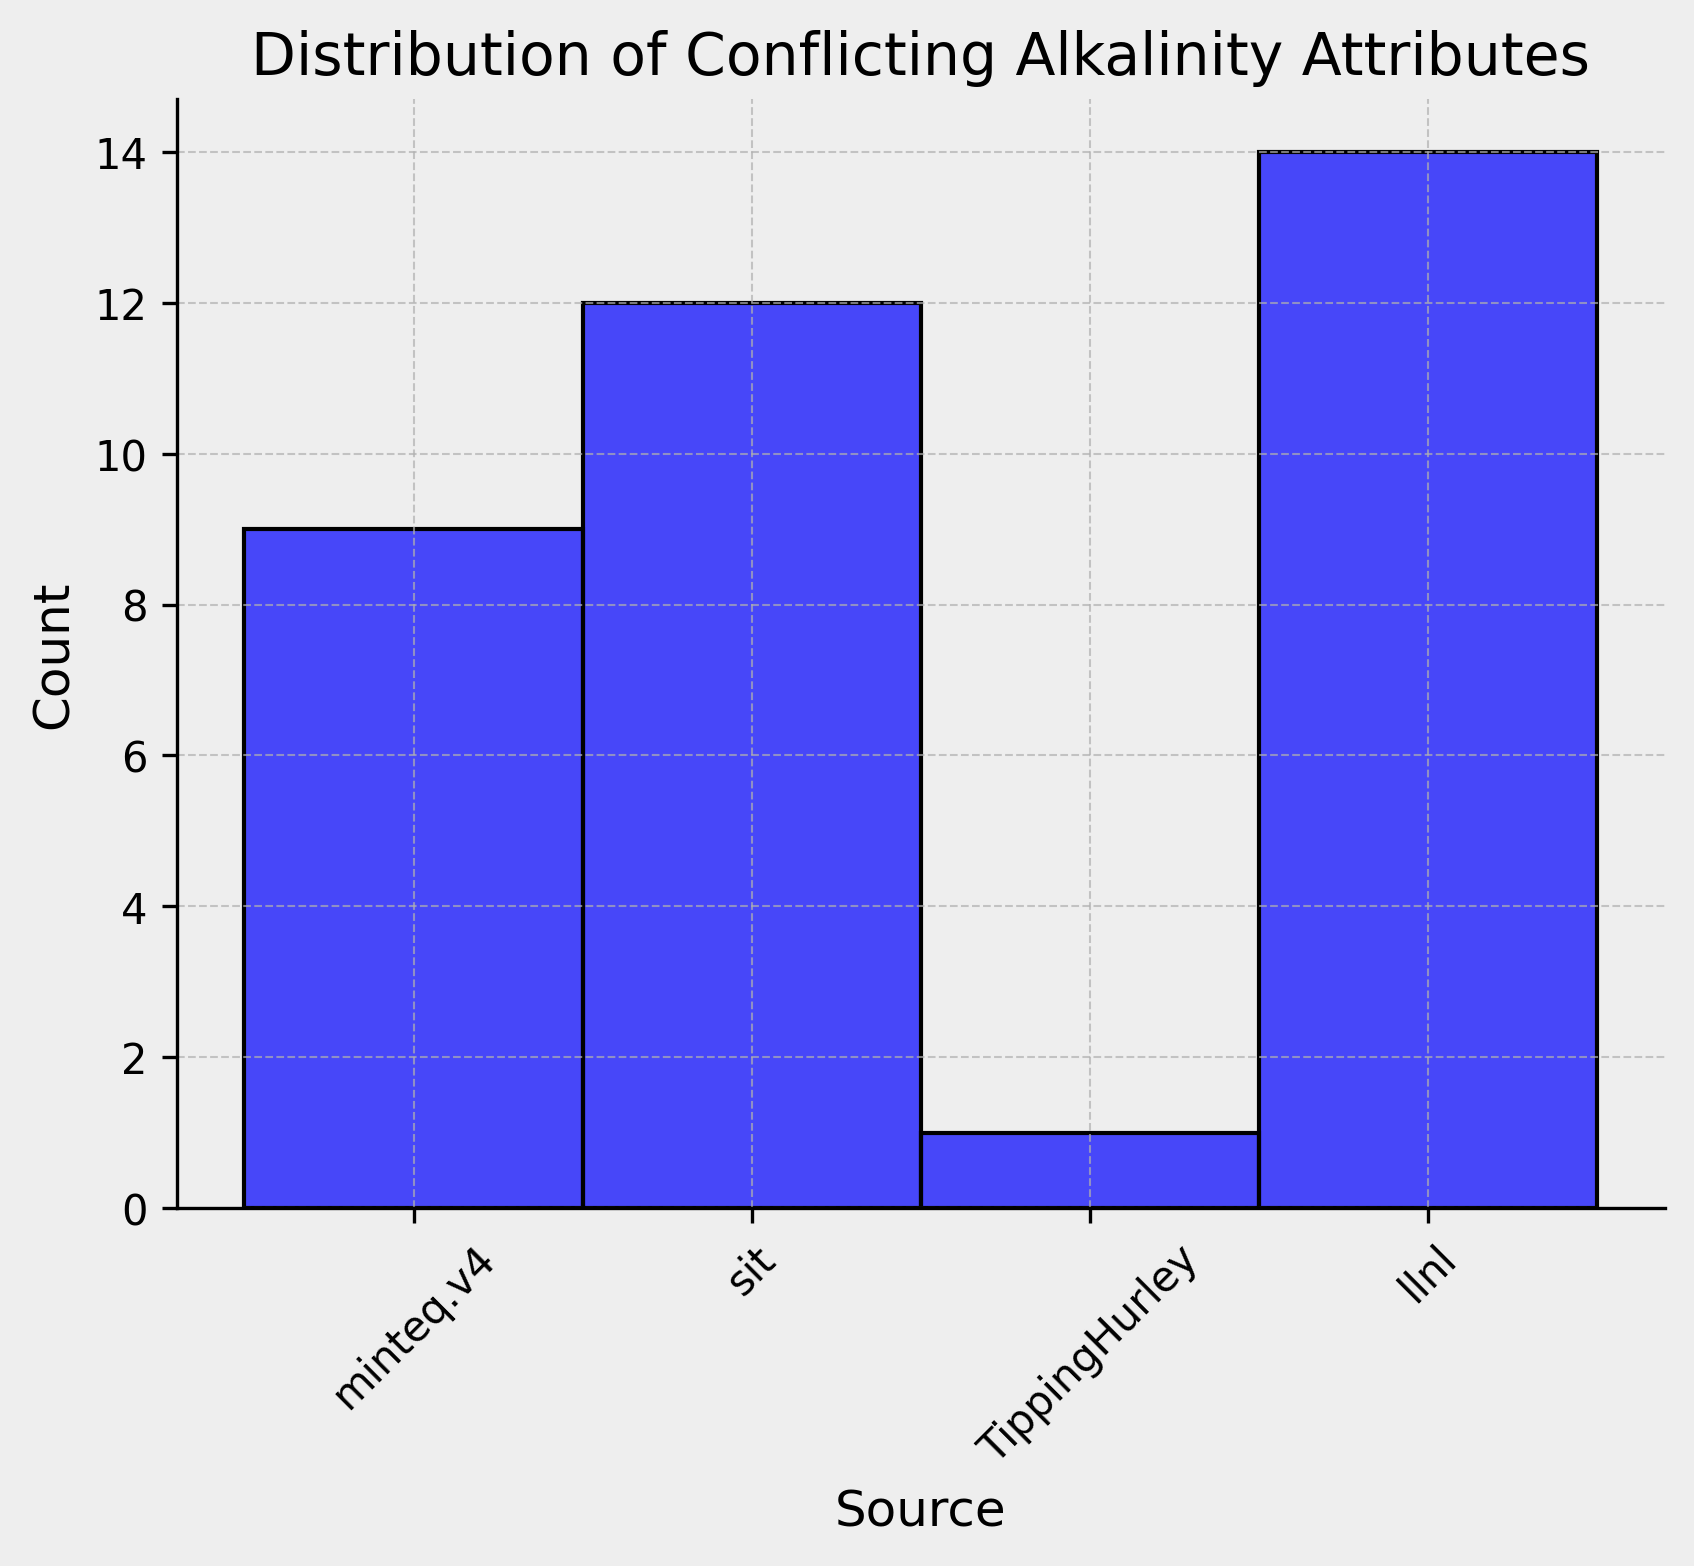

In [37]:
plot_source_hist(alk_dups_df, 'Distribution of Conflicting Alkalinity Attributes')

### GFW Conflict

In [38]:
gfw_dups_number, gfw_dups_df = alk_gfw_duplicates(sms, 'element_gfw')
gfw_dups_df = gfw_dups_df.dropna(subset=['element_gfw'])
gfw_dups_df['element_gfw'] = gfw_dups_df['element_gfw'].astype(float)
print(f"{gfw_dups_number} elements defined with different gfw attributes")
gfw_dups_df.head()


34 elements defined with different gfw attributes


,element,species,element_gfw,source
115,Acetate,Acetate-,59.0450,#minteq.v4.dat
1,Acetate,Acetate-,59.0100,#sit.dat
0,Ag,Ag+,107.8680,#Tipping_Hurley.dat
1,Ag,Ag+,107.8682,#llnl.dat
2,Alkalinity,CO3-2,50.0500,#Tipping_Hurley.dat


In [39]:
# calculate the range of gfw values for each element and return it to the gfw_dups_df dataframe
gfw_range = gfw_dups_df.groupby(['element', 'species'])['element_gfw'].agg(lambda x: x.max() - x.min())
gfw_dups_df = gfw_dups_df.merge(gfw_range, on=['element', 'species'], suffixes=('', '_range'), how='inner').sort_values(by=['element_gfw_range'], ascending=False)


,element,species,element_gfw,source,element_gfw_range


In [64]:
gfw_dups_df[gfw_dups_df['element_gfw_range'] >= 0.01]

,element,species,element_gfw,source,element_gfw_range
4,Alkalinity,CO3-2,50.0500,#Tipping_Hurley.dat,10.9673
5,Alkalinity,CO3-2,61.0173,#minteq.v4.dat,10.9673
0,Acetate,Acetate-,59.0450,#minteq.v4.dat,0.0350
1,Acetate,Acetate-,59.0100,#sit.dat,0.0350
47,Ni,Ni+2,58.7100,#Tipping_Hurley.dat,0.0200
48,Ni,Ni+2,58.6900,#llnl.dat,0.0200
76,Zn,Zn+2,65.3900,#llnl.dat,0.0200
75,Zn,Zn+2,65.3700,#Tipping_Hurley.dat,0.0200
30,Cyanide,Cyanide-,26.0000,#llnl.dat,0.0177
29,Cyanide,Cyanide-,26.0177,#minteq.v4.dat,0.0177


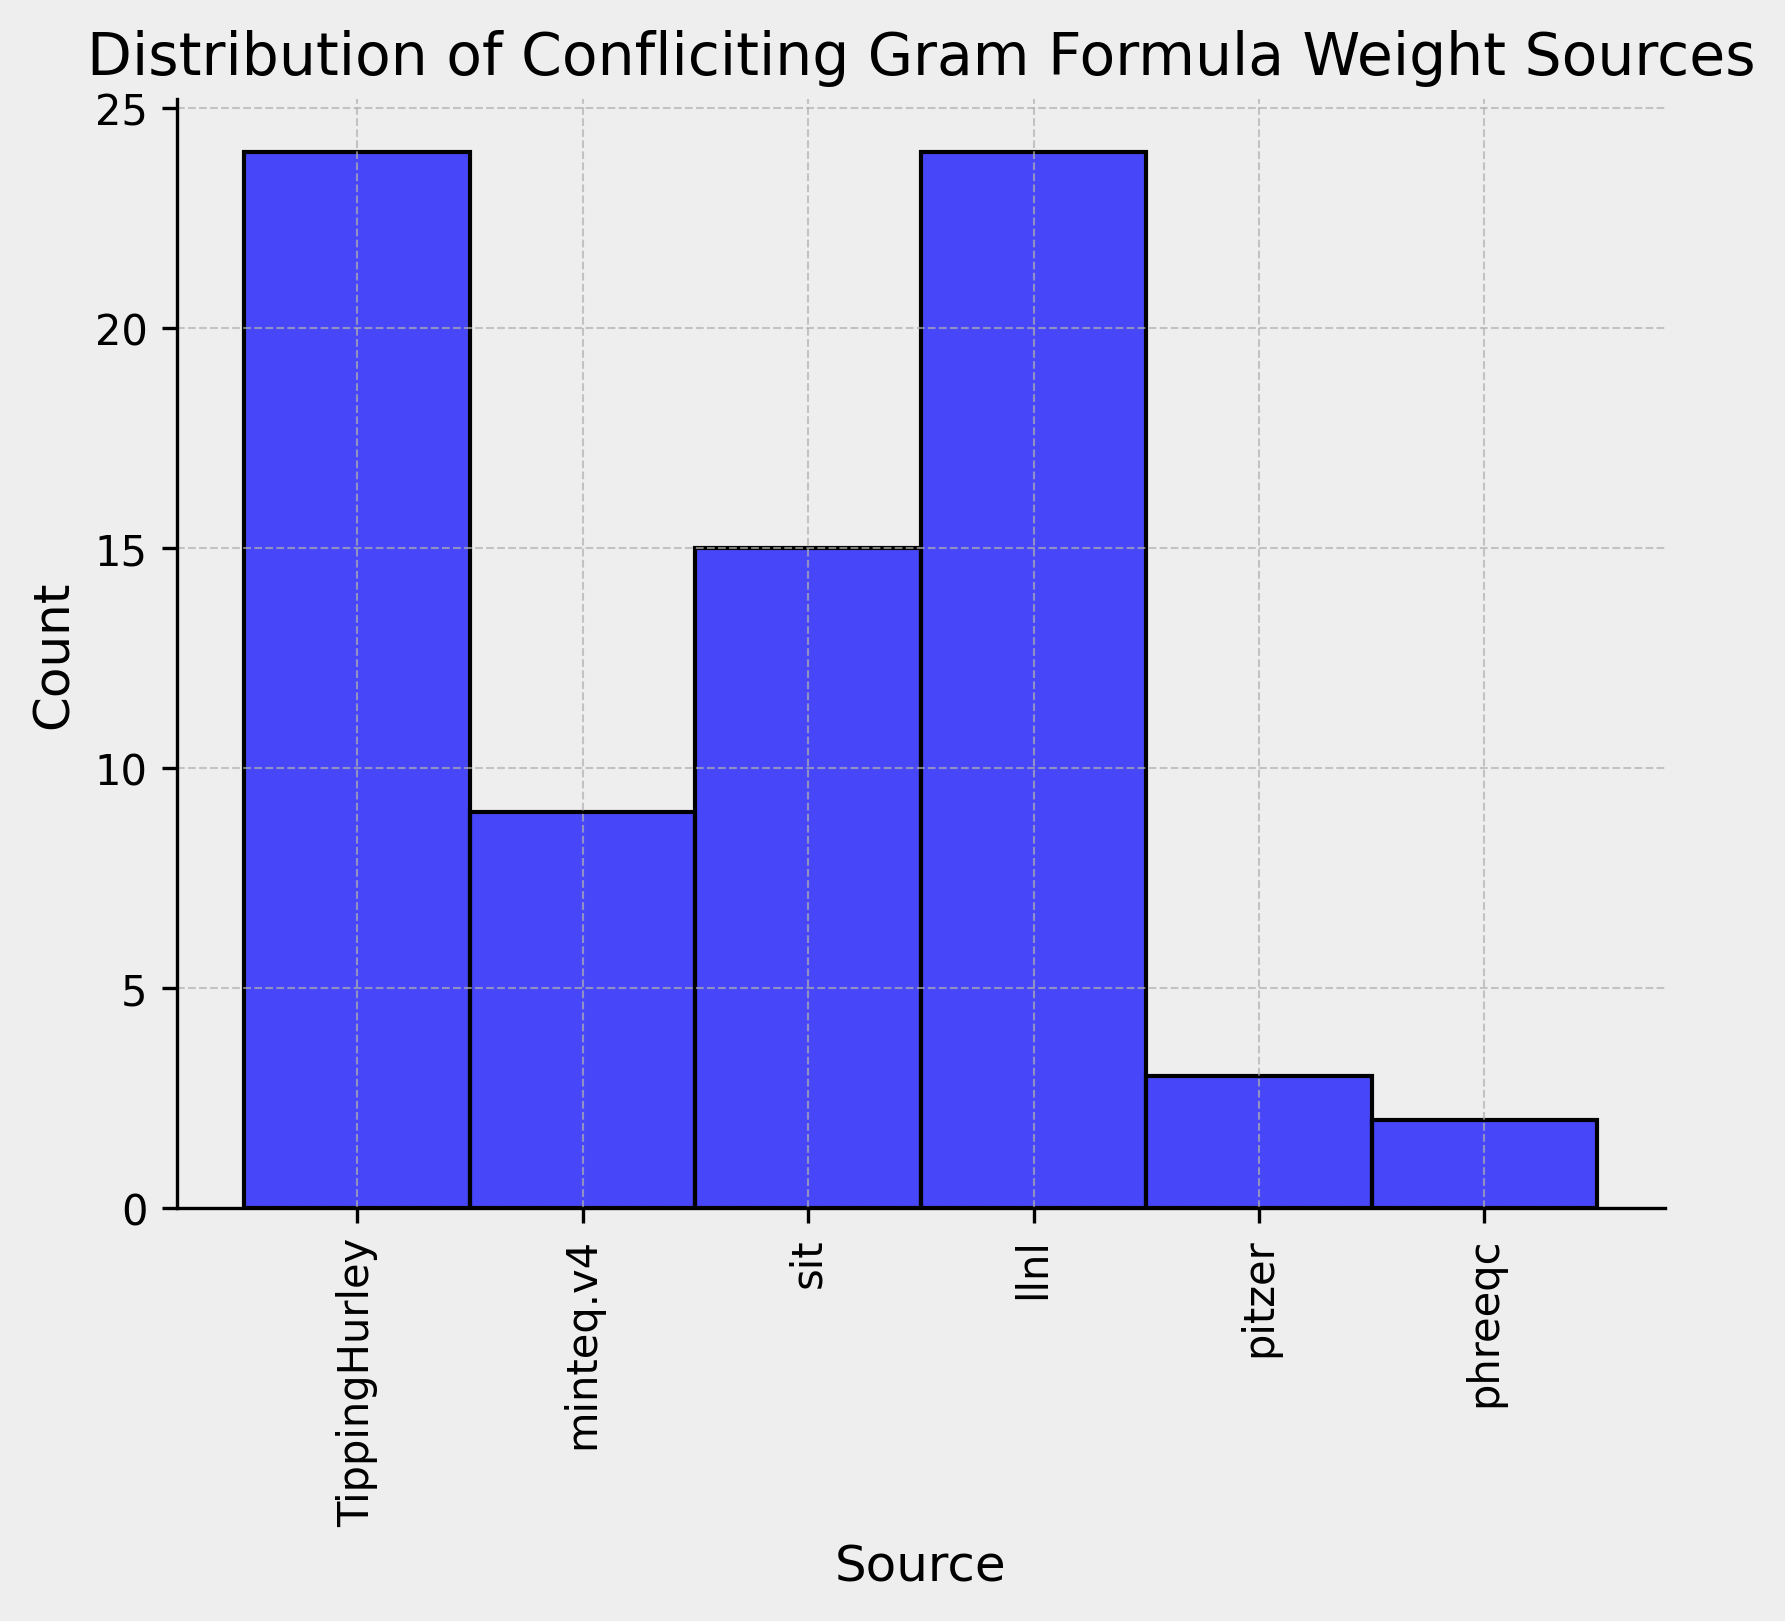

In [40]:
plot_source_hist(gfw_dups_df, 'Distribution of Confliciting Gram Formula Weight Sources', rotation=90)

### Species Conflict

In [41]:
(sms.drop_duplicates(subset=['element', 'species']).groupby('element').nunique()['species'] > 1).sum()

np.int64(35)

In [42]:
species_dups = sms.drop_duplicates(subset=['element', 'species']).sort_values(by=['element'])
species_dups = species_dups[species_dups.duplicated(subset=['element'], keep=False)]
print(f"{species_dups['element'].nunique()} elements defined with different species")
species_dups.head()

35 elements defined with different species


,element,species,alk,gfw_formula,element_gfw,source
0,Acetate,HAcetate,0.0,Acetate,59.,#llnl.dat
1,Acetate,Acetate-,0.0,Acetate,59.01,#sit.dat
2,Alkalinity,CO3-2,1.0,50.05,50.05,#Tipping_Hurley.dat
5,Alkalinity,HCO3-,1.0,Ca0.5(CO3)0.5,50.05,#llnl.dat
12,As,AsO4-3,0.0,As,74.9216,#sit.dat


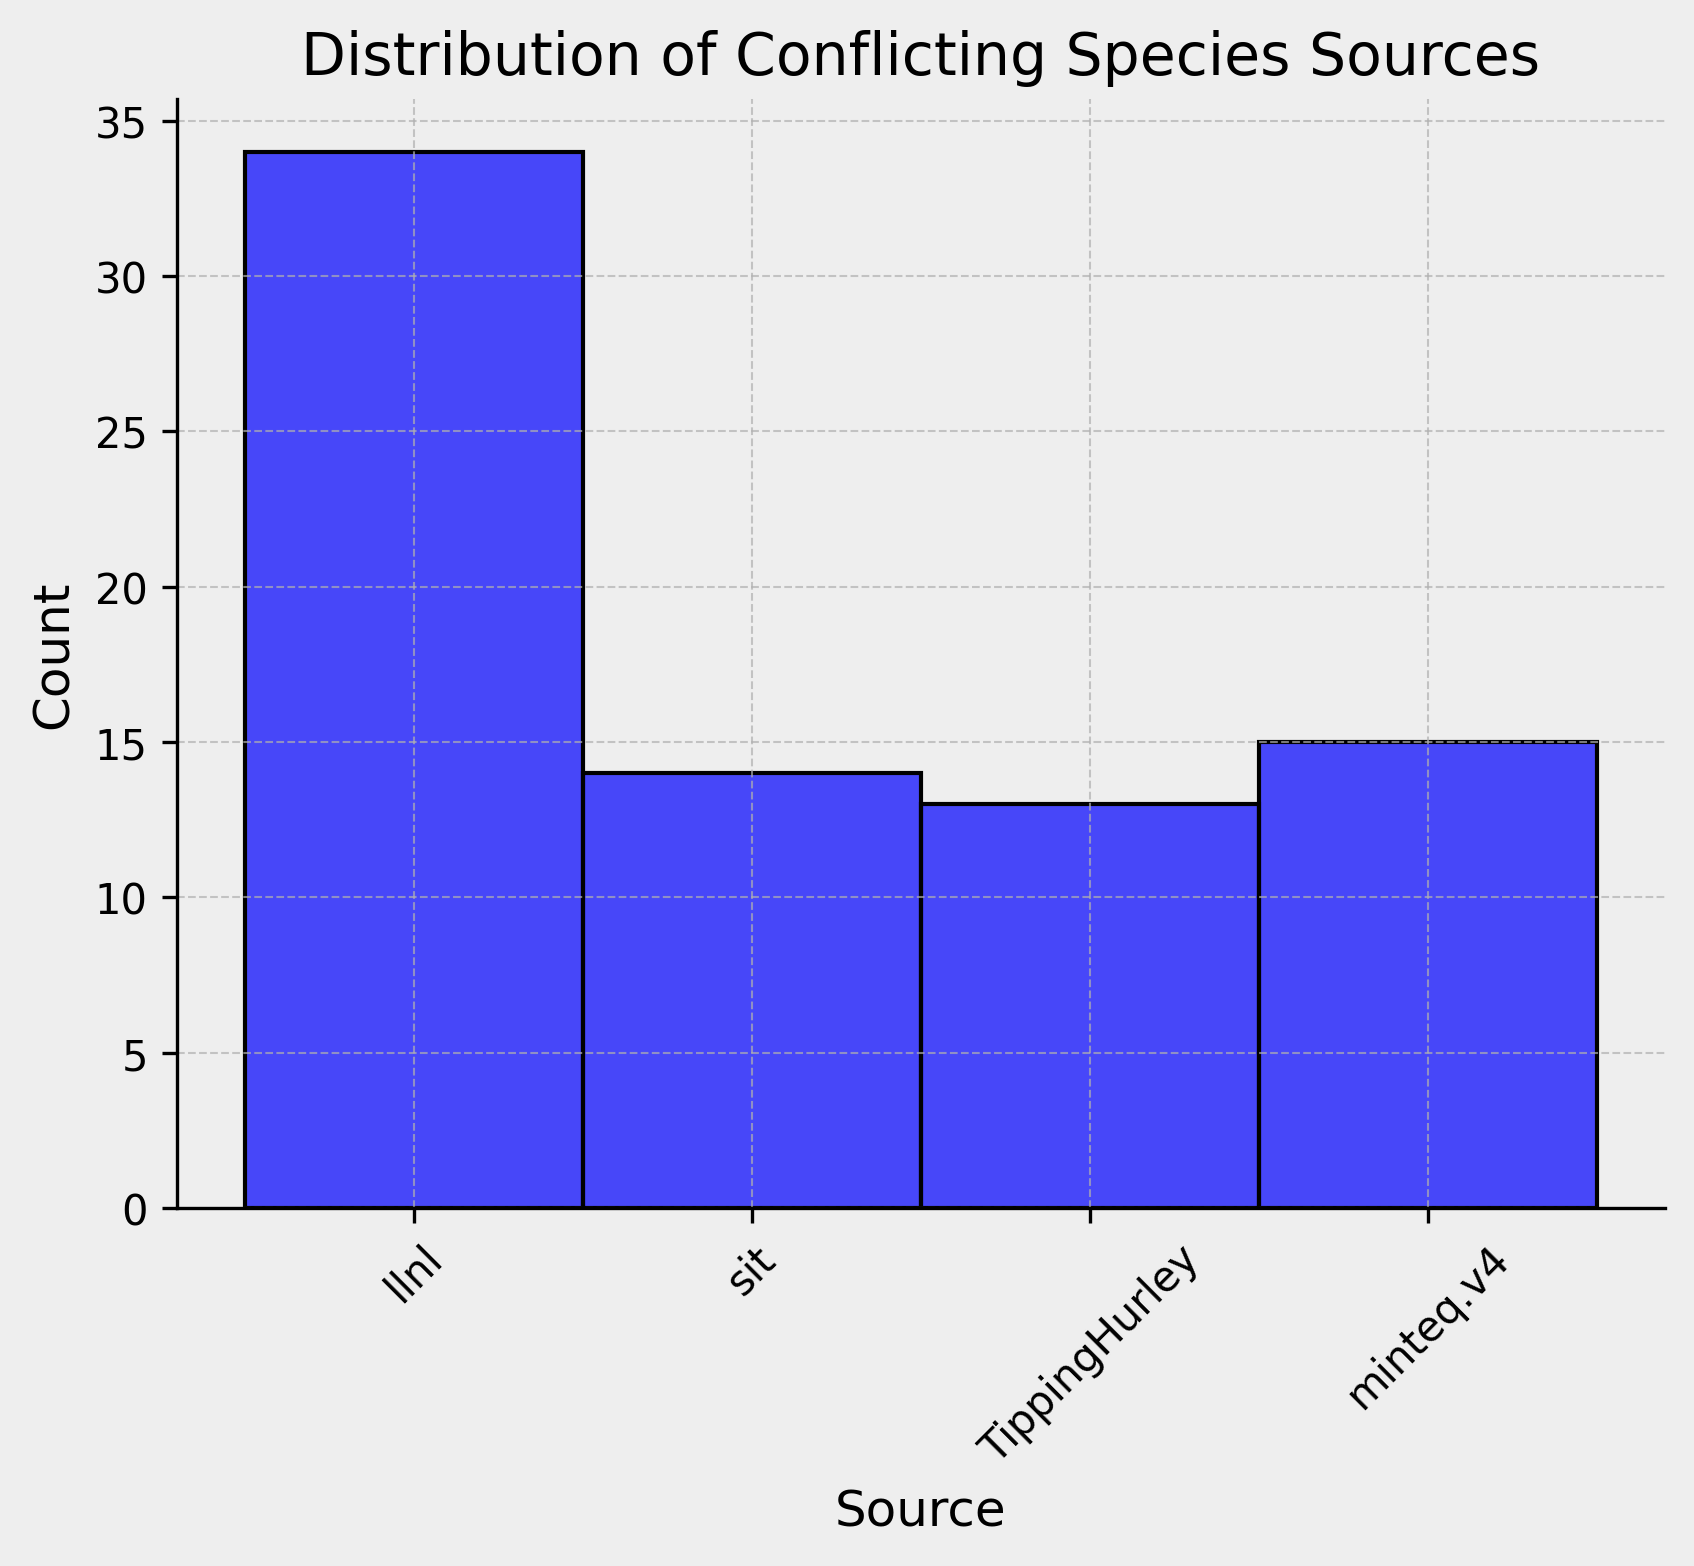

In [43]:
plot_source_hist(species_dups, 'Distribution of Conflicting Species Sources')

### What elements are most often have conflicting definitions?

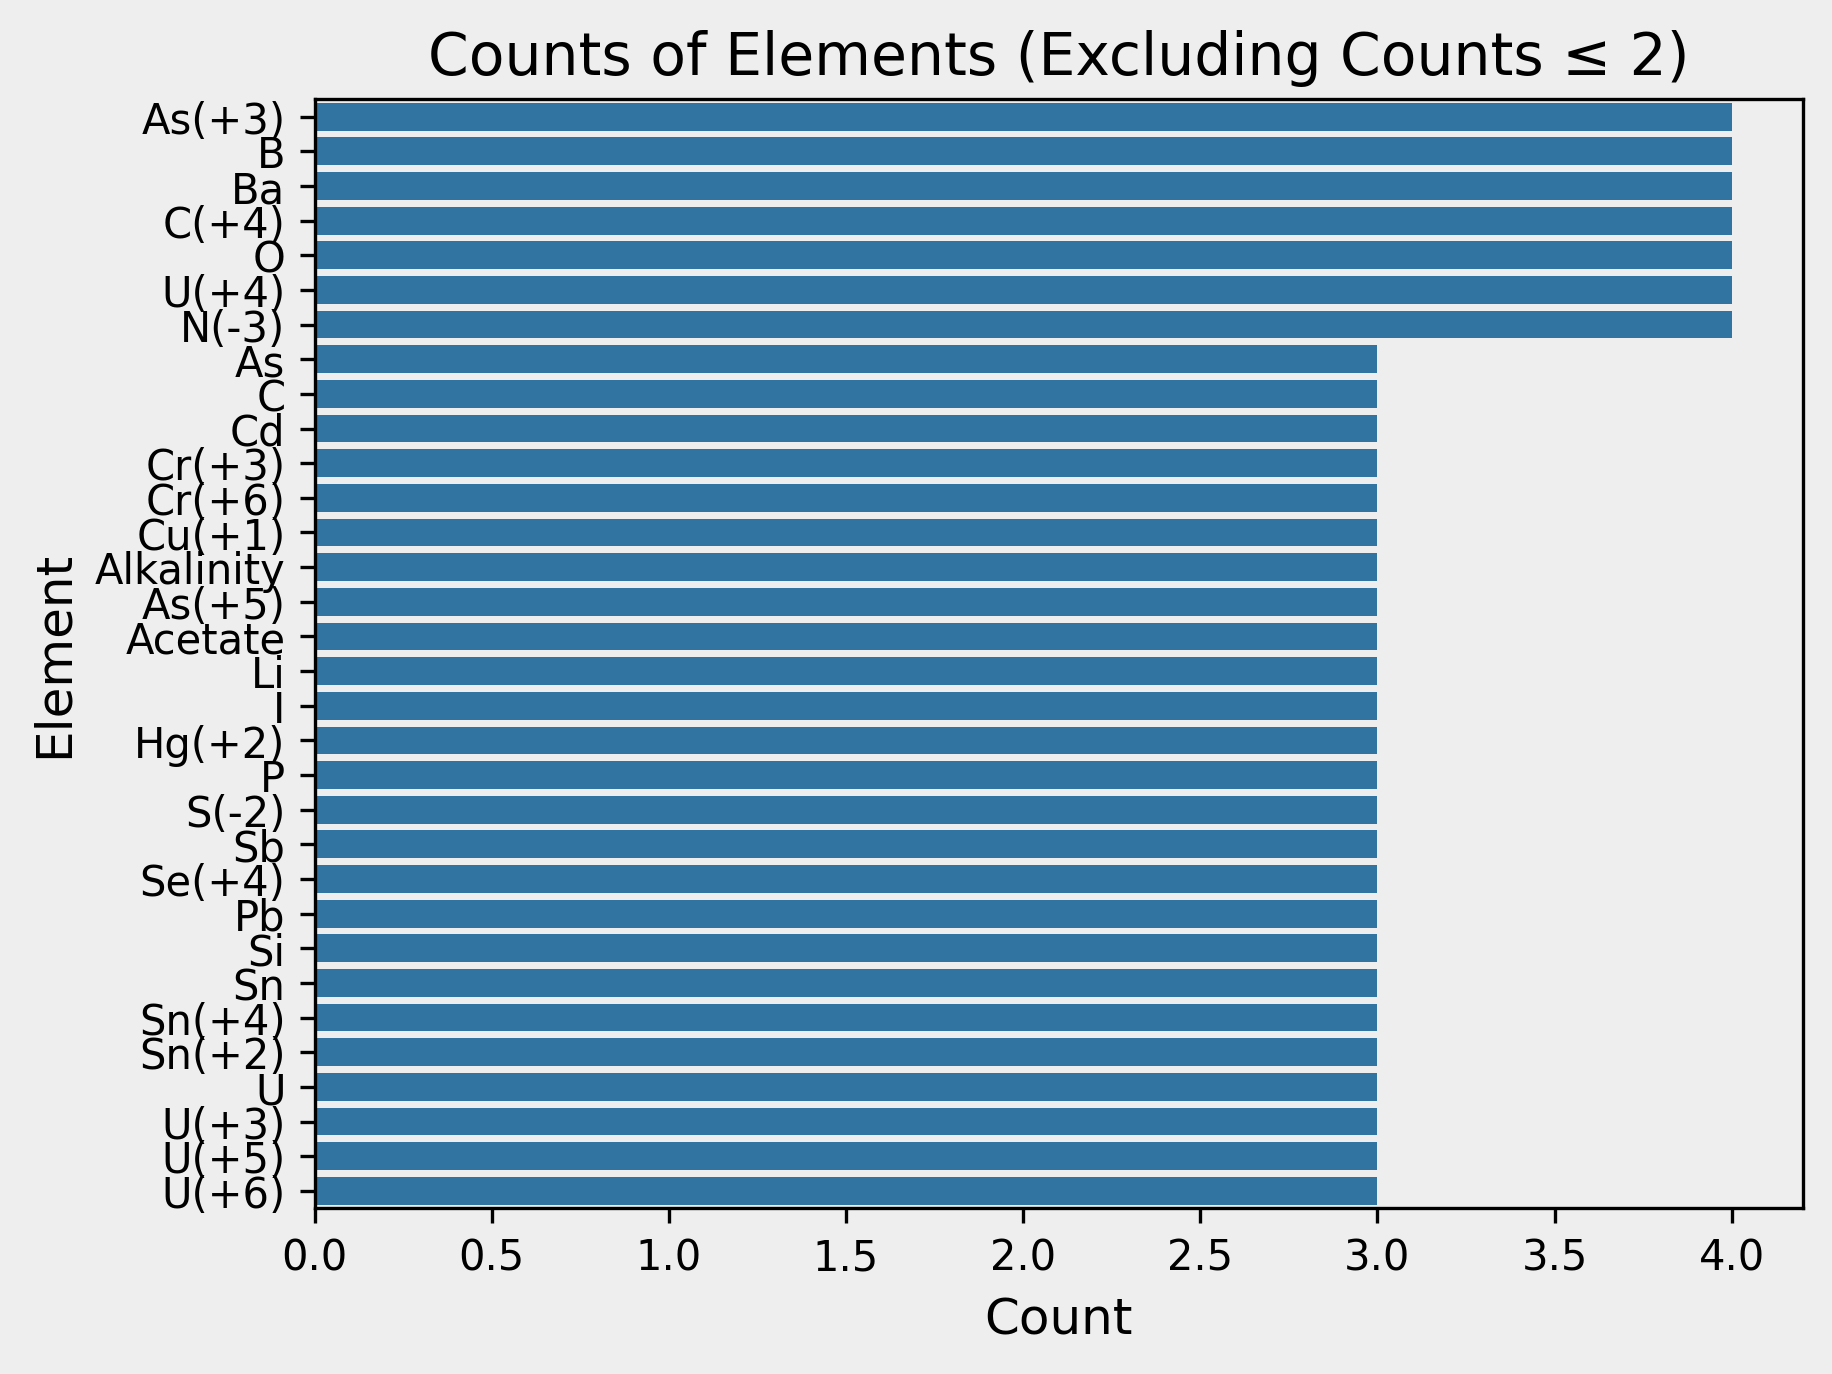

In [44]:
element_counts = sms['element'].value_counts()
filtered_elements = element_counts[element_counts > 2].index
filtered_sms = sms[sms['element'].isin(filtered_elements)]
sorted_counts = filtered_sms['element'].value_counts().sort_values(ascending=False)
sns.barplot(y=sorted_counts.index, x=sorted_counts.values)
plt.xlabel('Count')
plt.ylabel('Element')
plt.title('Counts of Elements (Excluding Counts ≤ 2)')
plt.show()

## Examine Solution Species

### How many equations do each database have?

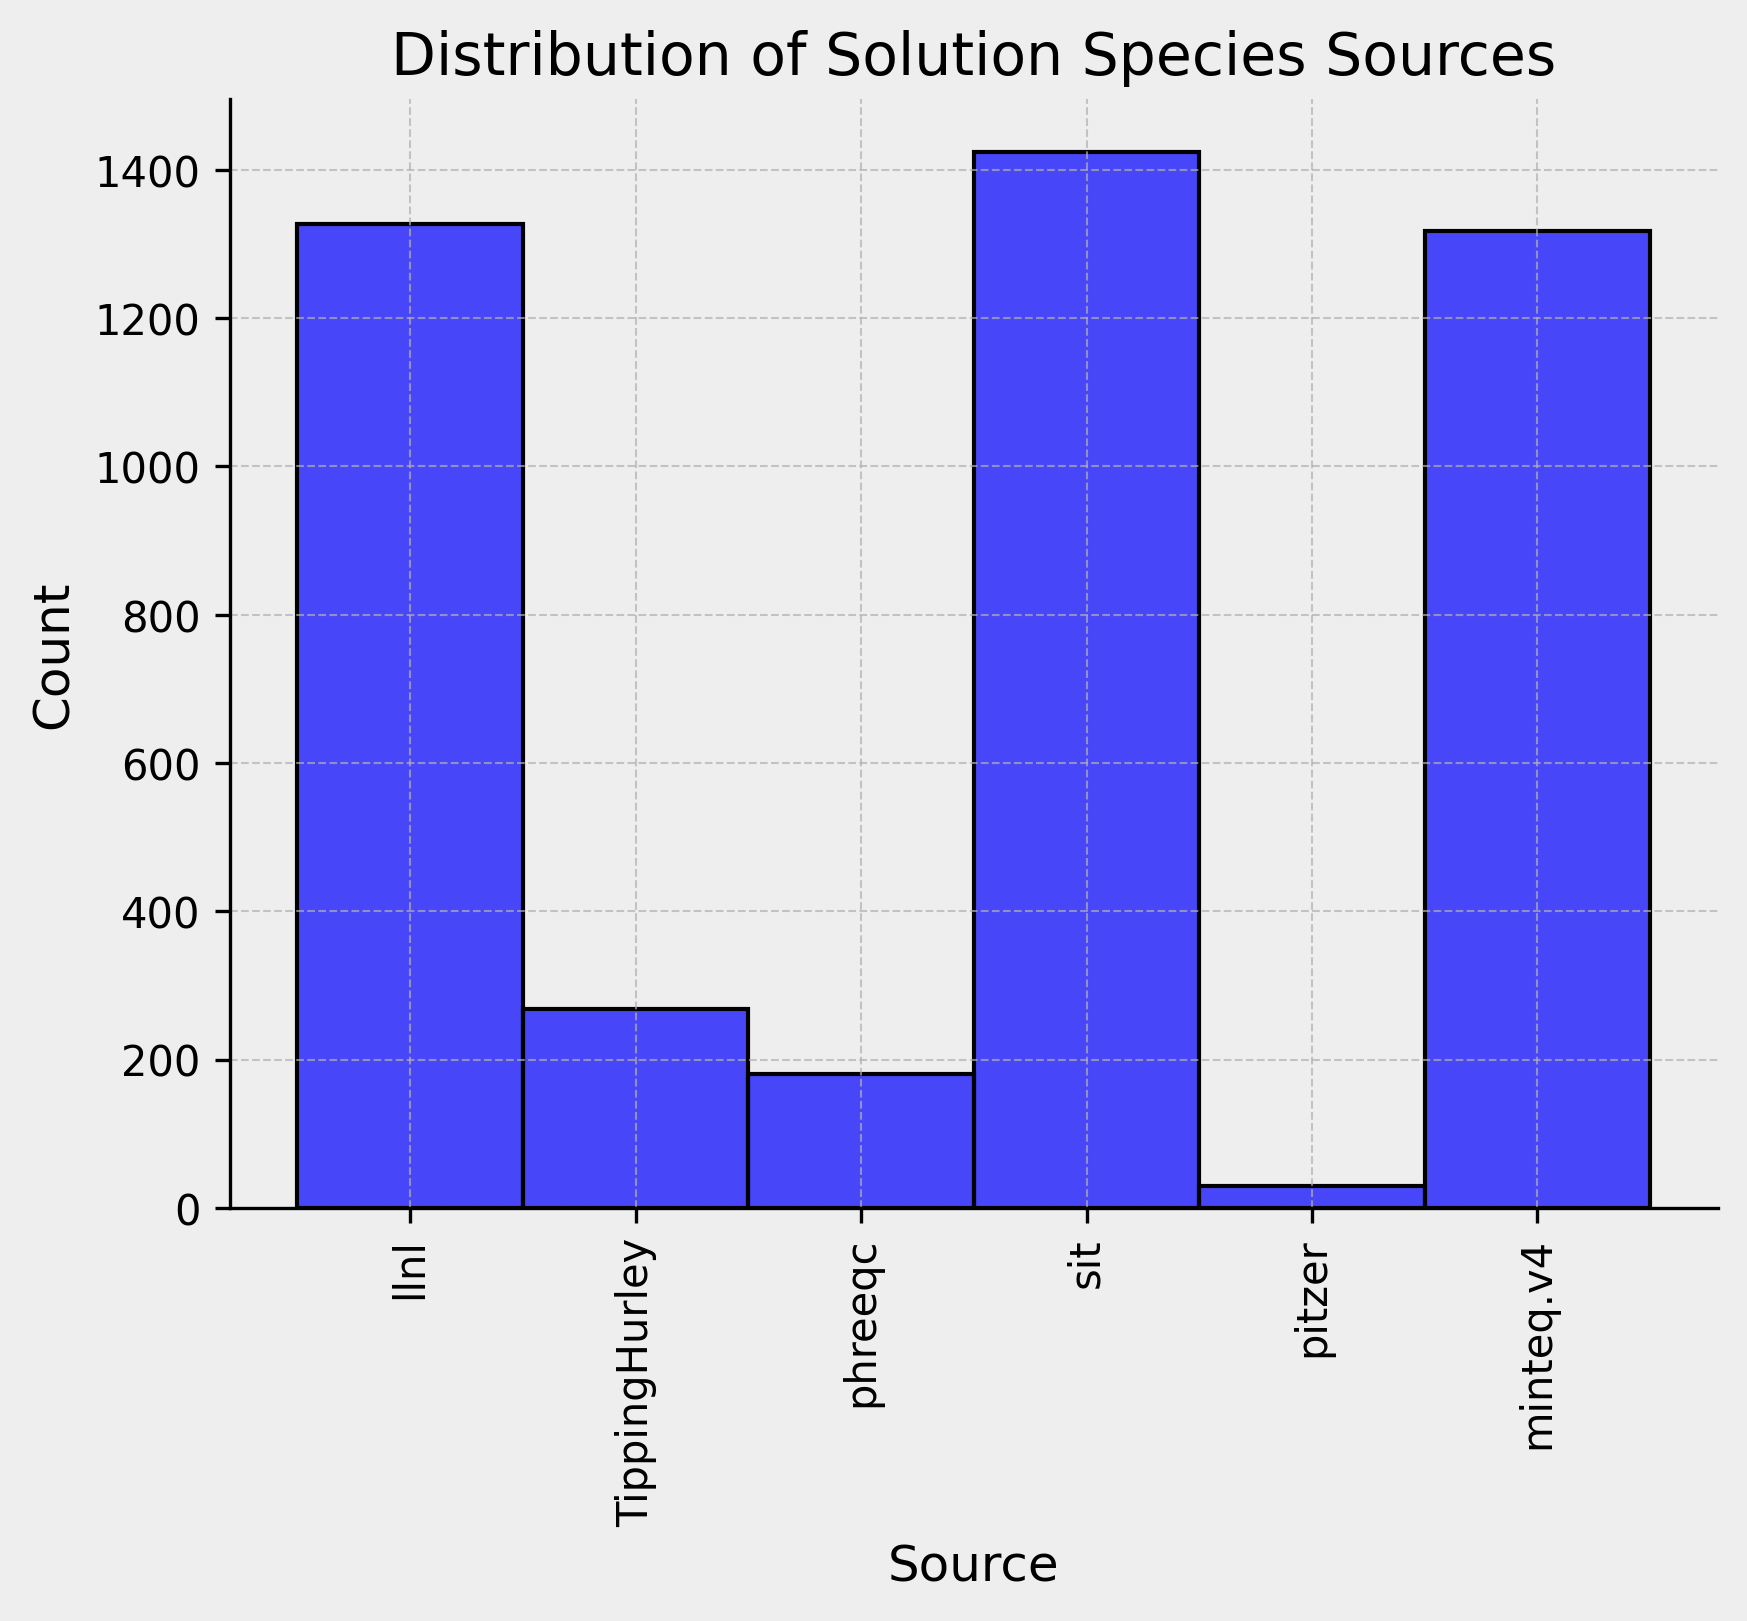

In [45]:
plot_source_hist(solution_species, 'Distribution of Solution Species Sources', rotation=90)

### How many equations have conflicting log k values?

In [46]:
(solution_species.groupby('equation').nunique() > 1).sum()

log_k             155
delta_h           112
gamma              97
d_w                 1
v_m                 3
millero             0
activity_water      0
add_logk            0
co2_llnl_gamma      0
erm_ddl             0
no_check            0
mole_balance        0
source            246
dtype: int64

This is a naive look at the number of conflicting values defined for each equation. There are 155 conflicting log K values amoung the databases, 122 conflicting delta h values, etc. Small differences in entry style or notation are missed with the method. Its difficult to guess every way an entry might be  different, but we can take a closer look at log_k as an example. Equations from different databases will have varying amounts of whitespace in the equation. Some databases use "floating point" representations of integers while others use only integers. SIT has three decimal precision for their floats, while LLNL has four. Both of these databases represent the implicit stockometric 1 with 1.000 or 1.0000. If we correct for some of these differeces in style, we can gather a few more equations that have conflicting log k values.

In [47]:
import copy
equation_dups = copy.deepcopy(solution_species)
equation_dups.iloc[:,0] = equation_dups.iloc[:,0].str.replace(' ', '')
ones = re.compile(r'\b1(?!\d)')
equation_dups.iloc[:,0] = equation_dups.iloc[:,0].str.replace(ones, '', regex=True)
equation_dups = equation_dups.drop_duplicates(subset=['equation', 'log_k'])
equation_dups = equation_dups[equation_dups.duplicated(subset=['equation'], keep=False)].sort_values(by=['equation'])
equation_dups = equation_dups.drop(index=equation_dups[equation_dups['log_k'] == 0].index, axis=0) # remove rows with log k = 0
print(f"{equation_dups['equation'].nunique()} equations defined with different log k values")
print(f"{equation_dups['source'].value_counts()}")
equation_dups.sort_values(by=['equation']).head()

302 equations defined with different log k values
source
minteq.v4.dat         226
Tipping_Hurley.dat    169
sit.dat               139
llnl.dat              111
phreeqc.dat            13
pitzer.dat              5
Name: count, dtype: int64


,equation,log_k,delta_h,gamma,d_w,v_m,millero,activity_water,add_logk,co2_llnl_gamma,erm_ddl,no_check,mole_balance,source
1502,2Cd+2+H2O=Cd2OH+3+H+,-9.3900,"(10.9, kcal)",None,None,None,None,None,None,None,None,False,None,Tipping_Hurley.dat
3701,2Cd+2+H2O=Cd2OH+3+H+,-9.3970,"(45.81, kJ)","(0, 0)",None,None,None,None,None,None,None,False,None,minteq.v4.dat
306,2Cd+2+H2O=Cd2OH+3+H+,-9.3851,"(0,)",None,None,None,None,None,None,None,None,False,None,llnl.dat
2528,2Cl-+Cr+3=CrCl2+,-0.7100,"(20.920,)",None,None,None,None,None,None,None,None,False,None,sit.dat
385,2Cl-+Cr+3=CrCl2+,0.1596,"(41.2919, kJ/mol)",None,None,None,None,None,None,None,None,False,None,llnl.dat


In [48]:
range = equation_dups.groupby('equation')['log_k'].agg(lambda x: x.max() - x.min()).sort_values(ascending=False)
range

equation
3SO4-2+Zr+4=Zr(SO4)3-2    6.9993
2SO4-2+Zr+4=Zr(SO4)2      5.2435
H3AsO3=AsO3-3+3H+         4.8060
HS-=S-2+H+                4.3820
5F-+Zr+4=ZrF5-            4.2902
                           ...  
H3BO3+F-=BF(OH)3-         0.0010
Zn+2+4Cl-=ZnCl4-2         0.0010
H++CO3-2=HCO3-            0.0010
Cu+2+3HS-=Cu(HS)3-        0.0010
Co+2+H++CO3-2=CoHCO3+     0.0001
Name: log_k, Length: 302, dtype: float64

### Which equations have the most instances of different log k values?

In [49]:
ed = equation_dups['equation'].value_counts().head(15)
ed

equation
Pb+2+I-=PbI+              4
Mn+2+Cl-=MnCl+            4
Mn+2+F-=MnF+              4
Pb+2+F-=PbF+              4
Fe+3+F-=FeF+2             4
Pb+2+Cl-=PbCl+            4
Mg+2+F-=MgF+              4
Na++F-=NaF                4
Cd+2+Br-=CdBr+            4
Ni+2+Cl-=NiCl+            4
Pb+2+2CO3-2=Pb(CO3)2-2    3
Zn+2+SO4-2=ZnSO4          3
Ni+2+F-=NiF+              3
Sr+2+F-=SrF+              3
Ag++3I-=AgI3-2            3
Name: count, dtype: int64

In [50]:
for equation in ed.index:
    print(equation)
    print(equation_dups[equation_dups['equation'] == equation][['log_k', 'source']])

Pb+2+I-=PbI+
       log_k              source
3077  1.9800             sit.dat
1567  1.9400  Tipping_Hurley.dat
895   1.9597            llnl.dat
3915  2.0000       minteq.v4.dat
Mn+2+Cl-=MnCl+
       log_k              source
3872  0.1000       minteq.v4.dat
1447  0.6100  Tipping_Hurley.dat
2857  0.3000             sit.dat
746   0.3013            llnl.dat
Mn+2+F-=MnF+
      log_k              source
2860   0.85             sit.dat
1452   0.84  Tipping_Hurley.dat
3798   1.60       minteq.v4.dat
748    1.43            llnl.dat
Pb+2+F-=PbF+
       log_k              source
3074  2.2700             sit.dat
1518  1.2500  Tipping_Hurley.dat
3777  1.8480       minteq.v4.dat
891   0.8284            llnl.dat
Fe+3+F-=FeF+2
       log_k              source
533   4.1365            llnl.dat
2670  6.1300             sit.dat
3795  6.0400       minteq.v4.dat
1442  6.2000  Tipping_Hurley.dat
Pb+2+Cl-=PbCl+
       log_k              source
886   1.4374            llnl.dat
3070  1.4400             sit.da